Ảnh: 4678.jpg, Kích thước: (640, 640, 3)
Ảnh: 416.jpg, Kích thước: (152, 194, 3)
Ảnh: 4497.jpg, Kích thước: (640, 640, 3)
Ảnh: 4450.jpg, Kích thước: (640, 640, 3)
Ảnh: 3164.jpg, Kích thước: (416, 416, 3)
Ảnh: 887.jpg, Kích thước: (416, 416, 3)
Ảnh: 3263.jpg, Kích thước: (416, 416, 3)
Ảnh: 4796.jpg, Kích thước: (640, 640, 3)
Ảnh: 3758.jpg, Kích thước: (416, 416, 3)


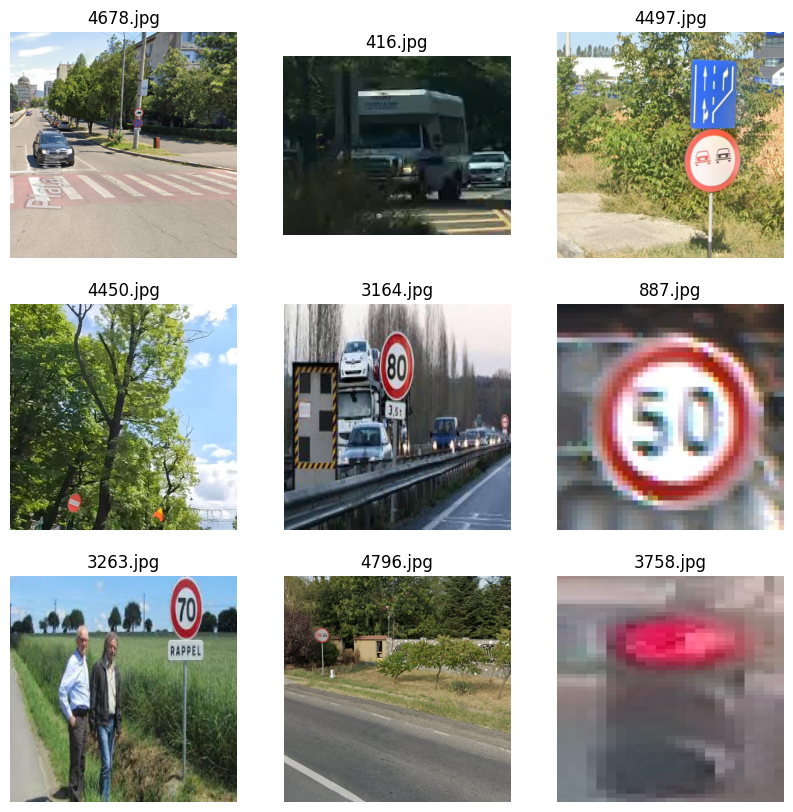

In [2]:
# EDA với bài toán Traffic Violation Detection
# Import thư viện
import cv2 as cv
import matplotlib.pyplot as plt
import numpy as np
import os

# Đường dẫn đến thư mục chứa ảnh
dataset_path = r'./extracted_data/images/train'
# Lấy danh sách tất cả các tệp ảnh trong thư mục
# Lưu ý: Chỉ lấy các tệp có định dạng ảnh (ví dụ: .jpg, .png)
train_image_files = [f for f in os.listdir(dataset_path) if f.endswith(('.jpg', '.png'))]

# Hiển thị ngẫu nhiên 9 ảnh mẫu từ tập dữ liệu và kiểm tra kích thước của chúng
plt.figure(figsize=(10, 10))
for i in range(9):
    # Chọn ngẫu nhiên một tệp ảnh
    img_file = np.random.choice(train_image_files)
    # Đọc ảnh bằng OpenCV
    img_path = os.path.join(dataset_path, img_file)
    img = cv.imread(img_path)
    # Kiểm tra kích thước của ảnh
    print(f"Ảnh: {img_file}, Kích thước: {img.shape}")
    # Hiển thị ảnh (chuyển đổi từ BGR sang RGB để hiển thị đúng màu)
    plt.subplot(3, 3, i + 1)
    plt.imshow(cv.cvtColor(img, cv.COLOR_BGR2RGB))
    plt.title(img_file)
    plt.axis('off')

Trung bình kích thước ảnh: [430.53521127 430.47487628   3.        ]
Độ lệch chuẩn kích thước ảnh: [124.57166275 129.52930819   0.        ]
Kích thước ảnh nhỏ nhất: [80 80  3]
Kích thước ảnh lớn nhất: [ 720 1276    3]


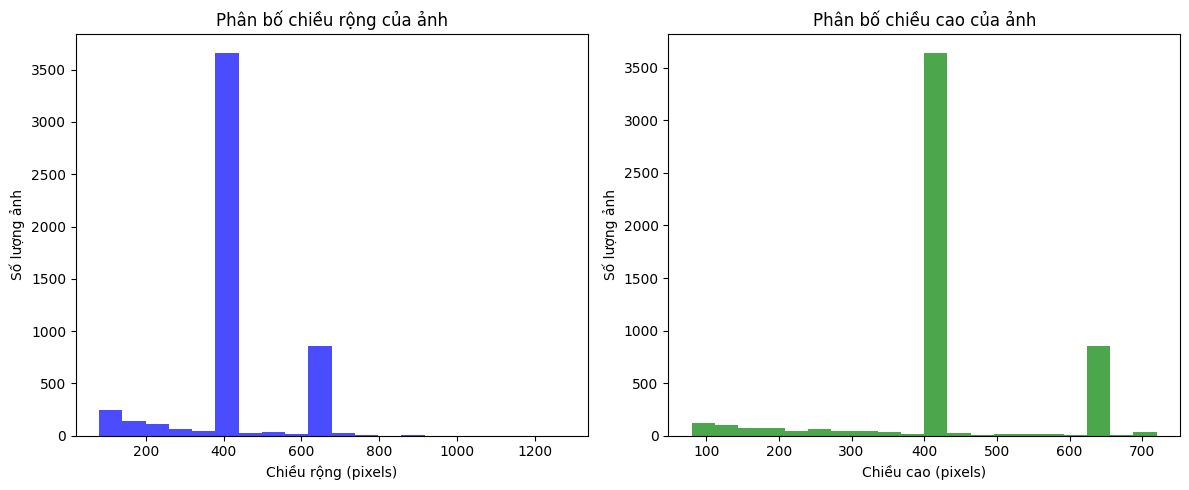

Top 2 kích thước ảnh phổ biến nhất:
Kích thước: (np.int64(416), np.int64(416), np.int64(3)), Số lượng: 3618
Kích thước: (np.int64(640), np.int64(640), np.int64(3)), Số lượng: 842


In [3]:
# Thống kê kích thước của tất cả ảnh trong tập dữ liệu
image_sizes = []
for img_file in train_image_files:
    img_path = os.path.join(dataset_path, img_file)
    img = cv.imread(img_path)
    image_sizes.append(img.shape)
# Chuyển đổi danh sách kích thước thành mảng NumPy để dễ dàng phân tích
image_sizes = np.array(image_sizes)
# Tính toán thống kê về kích thước ảnh
print(f"Trung bình kích thước ảnh: {np.mean(image_sizes, axis=0)}")
print(f"Độ lệch chuẩn kích thước ảnh: {np.std(image_sizes, axis=0)}")
print(f"Kích thước ảnh nhỏ nhất: {np.min(image_sizes, axis=0)}")
print(f"Kích thước ảnh lớn nhất: {np.max(image_sizes, axis=0)}")

# Đếm số lượng ảnh và phân loại theo kích thước
size_counts = {}
for size in image_sizes:
    size_tuple = tuple(size)
    if size_tuple in size_counts:
        size_counts[size_tuple] += 1
    else:
        size_counts[size_tuple] = 1

# Trực quan hóa phân bố chiều rộng và chiều cao của ảnh
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.hist(image_sizes[:, 1], bins=20, color='blue', alpha=0.7)
plt.title('Phân bố chiều rộng của ảnh')
plt.xlabel('Chiều rộng (pixels)')
plt.ylabel('Số lượng ảnh')
plt.subplot(1, 2, 2)
plt.hist(image_sizes[:, 0], bins=20, color='green', alpha=0.7)
plt.title('Phân bố chiều cao của ảnh')
plt.xlabel('Chiều cao (pixels)')
plt.ylabel('Số lượng ảnh')
plt.tight_layout()
plt.show()

# Top 2 kích thước ảnh phổ biến nhất
sorted_sizes = sorted(size_counts.items(), key=lambda x: x[1], reverse=True)
print("Top 2 kích thước ảnh phổ biến nhất:")
for size, count in sorted_sizes[:2]:
    print(f"Kích thước: {size}, Số lượng: {count}")



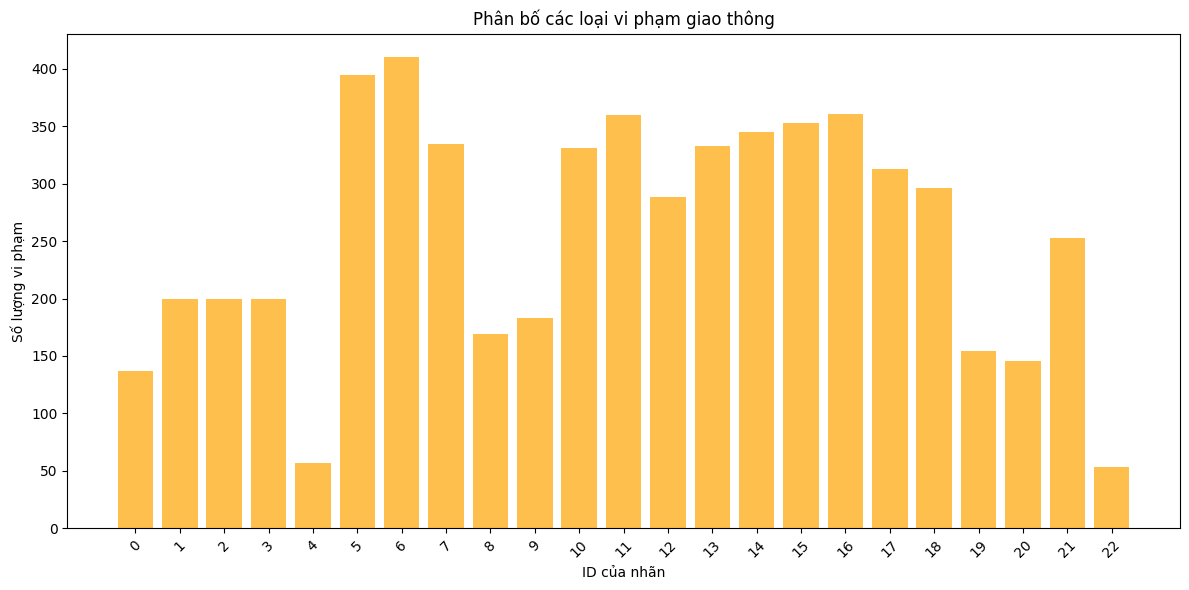

Thống kê số lượng các nhãn:
Số lượng: 410, Tên nhãn: green light
Số lượng: 395, Tên nhãn: red light
Số lượng: 361, Tên nhãn: speed limit 80
Số lượng: 360, Tên nhãn: speed limit 30
Số lượng: 353, Tên nhãn: speed limit 70
Số lượng: 345, Tên nhãn: speed limit 60
Số lượng: 335, Tên nhãn: stop sign
Số lượng: 333, Tên nhãn: speed limit 50
Số lượng: 331, Tên nhãn: speed limit 20
Số lượng: 313, Tên nhãn: speed limit 100
Số lượng: 296, Tên nhãn: speed limit 120
Số lượng: 288, Tên nhãn: speed limit 40
Số lượng: 253, Tên nhãn: no stopping
Số lượng: 200, Tên nhãn: truck
Số lượng: 200, Tên nhãn: car
Số lượng: 200, Tên nhãn: bus
Số lượng: 183, Tên nhãn: no overtaking
Số lượng: 169, Tên nhãn: no entry
Số lượng: 154, Tên nhãn: no left turn
Số lượng: 146, Tên nhãn: no right turn
Số lượng: 137, Tên nhãn: person
Số lượng: 57, Tên nhãn: motorcycle
Số lượng: 53, Tên nhãn: no u-turn


In [4]:
# Label overview

from turtle import speed


labels_path = r'./extracted_data/labels/train'
label_files = [f for f in os.listdir(labels_path) if f.endswith('.txt')]
# Đếm số lượng nhãn và phân loại theo loại vi phạm
dict_labels = {
    '0': 'person',
    '1': 'car',
    '2': 'truck',
    '3': 'bus',
    '4': 'motorcycle',
    '5': 'red light',
    '6': 'green light',
    '7': 'stop sign',
    '8': 'no entry',
    '9': 'no overtaking',
    '10': 'speed limit 20',
    '11': 'speed limit 30',
    '12': 'speed limit 40',
    '13': 'speed limit 50',
    '14': 'speed limit 60',
    '15': 'speed limit 70',
    '16': 'speed limit 80',
    '17': 'speed limit 100',
    '18': 'speed limit 120',
    '19': 'no left turn',
    '20': 'no right turn',
    '21': 'no stopping',
    '22': 'no u-turn'
}
label_counts = {}
for label_file in label_files:
    label_path = os.path.join(labels_path, label_file)
    with open(label_path, 'r') as f:
        lines = f.readlines()
        for line in lines:
            label_id = line.split()[0]  # Lấy ID của nhãn (phần đầu tiên của dòng)
            if label_id in label_counts:
                label_counts[label_id] += 1
            else:
                label_counts[label_id] = 1
# Trực quan hóa phân bố các loại vi phạm giao thông và săp xếp theoo ID tăng dần sử dụng Histogram
label_ids = sorted(label_counts.keys(), key=lambda x: int(x))
counts = [label_counts[label_id] for label_id in label_ids]
plt.figure(figsize=(12, 6))
plt.bar(label_ids, counts, color='orange', alpha=0.7)
plt.title('Phân bố các loại vi phạm giao thông')   
plt.xlabel('ID của nhãn')
plt.ylabel('Số lượng vi phạm')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Thống kê số lượng vi phạm theo từng loại và sắp xếp theo số lượng giảm dần
sorted_labels = sorted(label_counts.items(), key=lambda x: x[1], reverse=True)
print("Thống kê số lượng các nhãn:")
for label_id, count in sorted_labels:
    print(f"Số lượng: {count}, Tên nhãn: {dict_labels.get(label_id, 'Unknown')}")


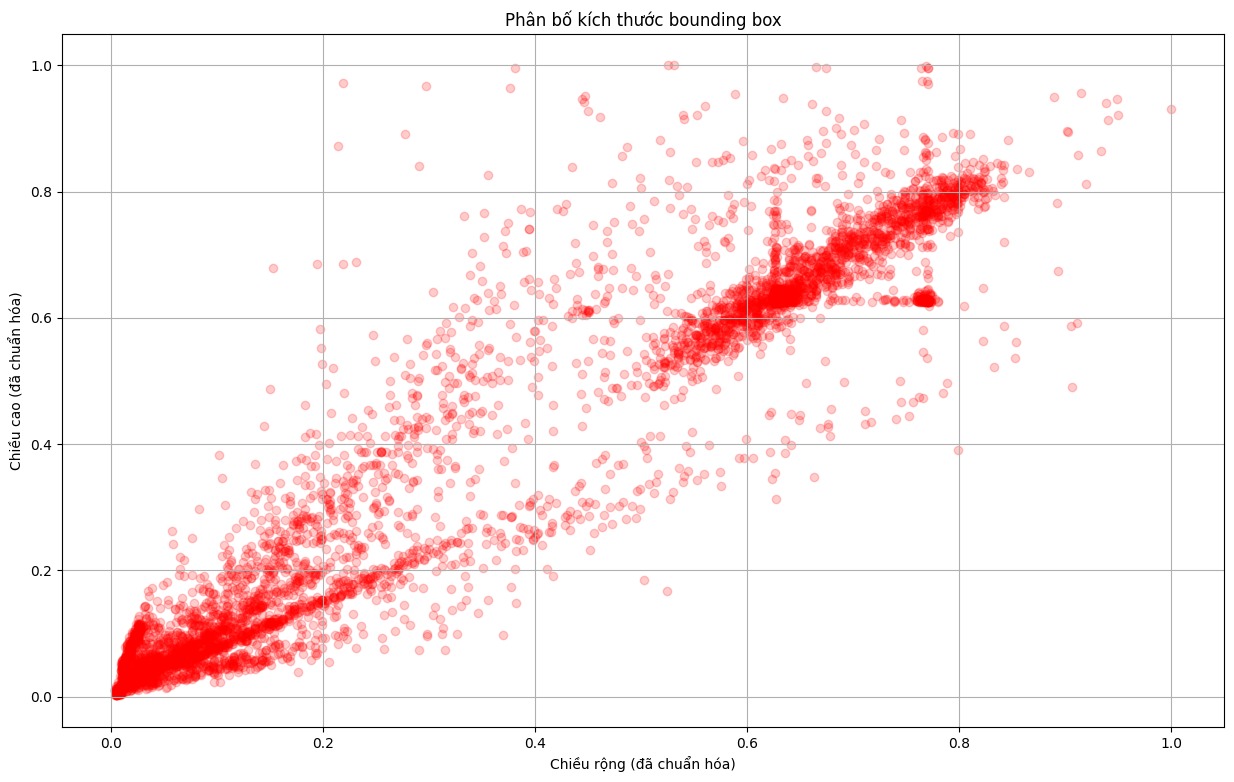

Trung bình kích thước bounding box: [0.36422439 0.37821949]
Độ lệch chuẩn kích thước bounding box: [0.28509553 0.29005208]
Kích thước bounding box nhỏ nhất: [0.00360577 0.00240385]
Kích thước bounding box lớn nhất: [1. 1.]


In [5]:
# Phân tích bounding box
# Đọc một số tệp nhãn để phân tích kích thước và vị trí của bounding box
bbox_sizes = []

for label_file in label_files: 
    label_path = os.path.join(labels_path, label_file)
    with open(label_path, 'r') as f:
        lines = f.readlines()
        for line in lines:
            parts = line.split()
            if len(parts) == 5:  # Đảm bảo có đủ thông tin về bounding box
                x_center = float(parts[1])  # Tọa độ trung tâm x (đã được chuẩn hóa)
                y_center = float(parts[2])  # Tọa độ trung tâm y (đã được chuẩn hóa)
                width = float(parts[3])     # Chiều rộng của bounding box (đã được chuẩn hóa)
                height = float(parts[4])    # Chiều cao của bounding box (đã được chuẩn hóa)
                bbox_sizes.append((width, height))  # Lưu kích thước bounding box vào danh sách
# Chuyển đổi danh sách kích thước bounding box thành mảng NumPy để dễ dàng phân tích và trực quan hóa kích thước của bounding box sử dụng scatter plot
bbox_sizes = np.array(bbox_sizes)
plt.figure(figsize=(15, 9))
plt.scatter(bbox_sizes[:, 0], bbox_sizes[:, 1], alpha=0.2, color='red')
plt.title('Phân bố kích thước bounding box')
plt.xlabel('Chiều rộng (đã chuẩn hóa)')
plt.ylabel('Chiều cao (đã chuẩn hóa)')
plt.grid()
plt.show()

# Thống kê kích thước bounding box
print(f"Trung bình kích thước bounding box: {np.mean(bbox_sizes, axis=0)}")
print(f"Độ lệch chuẩn kích thước bounding box: {np.std(bbox_sizes, axis=0)}")
print(f"Kích thước bounding box nhỏ nhất: {np.min(bbox_sizes, axis=0)}")
print(f"Kích thước bounding box lớn nhất: {np.max(bbox_sizes, axis=0)}")




In [6]:
# Kiểm tra xem có ảnh nào bị hỏng hoặc không thể đọc được không
corrupted_images = []
for img_file in train_image_files:
    img_path = os.path.join(dataset_path, img_file)
    img = cv.imread(img_path)
    if img is None:
        corrupted_images.append(img_file)
if corrupted_images:
    print("Các ảnh bị hỏng hoặc không thể đọc được:")
    for img_file in corrupted_images:
        print(img_file)
else:
    print("Không có ảnh nào bị hỏng hoặc không thể đọc được.")

Không có ảnh nào bị hỏng hoặc không thể đọc được.


In [9]:
# Kiểm tra chất lượng ảnh 
# Đếm số lượng ảnh có chất lượng thấp (ví dụ: quá mờ, quá sáng, quá tối)
low_quality_images = []
for img_file in train_image_files:
    img_path = os.path.join(dataset_path, img_file)
    img = cv.imread(img_path)
    if img is not None:
        gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)
        # Sử dụng phương pháp Laplacian để đánh giá độ sắc nét của ảnh
        laplacian_var = cv.Laplacian(gray, cv.CV_64F).var()
        if laplacian_var < 100:  # Ngưỡng để xác định ảnh mờ
            low_quality_images.append(img_file)
print(f"Số lượng ảnh có chất lượng thấp: {len(low_quality_images)}")


Số lượng ảnh có chất lượng thấp: 1181
